<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embeddings con Gensim


### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [2]:
# Descargar el dataset (versión cross-platform y sin dependencias de shell)
import os, urllib.request, zipfile

URL = ("https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/"
       "procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip")

if not os.path.isdir("songs_dataset"):
    if not os.path.isfile("songs_dataset.zip"):
        urllib.request.urlretrieve(URL, "songs_dataset.zip")
    with zipfile.ZipFile("songs_dataset.zip") as z:
        z.extractall(".")
    print("Dataset descargado")
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [3]:
# Posibles bandas
sorted(os.listdir("./songs_dataset/"))[:15]

['Kanye_West.txt',
 'Lil_Wayne.txt',
 'adele.txt',
 'al-green.txt',
 'alicia-keys.txt',
 'amy-winehouse.txt',
 'beatles.txt',
 'bieber.txt',
 'bjork.txt',
 'blink-182.txt',
 'bob-dylan.txt',
 'bob-marley.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'bruno-mars.txt']

### Tokenización liviana
El ejemplo de clase usaba `tensorflow.keras.preprocessing.text.text_to_word_sequence`. Para no arrastrar TensorFlow como dependencia, definimos un tokenizador equivalente con una expresión regular: pasa a minúsculas, normaliza las comillas tipográficas y conserva las contracciones del tipo `i'm`, `don't`.

In [4]:
def normalizar(texto):
    """Unifica comillas curvas a ASCII."""
    return (texto.replace("’", "'").replace("‘", "'")
                 .replace("“", '"').replace("”", '"'))

_TOKEN_RE = re.compile(r"[a-z']+")

def text_to_word_sequence(texto):
    toks = _TOKEN_RE.findall(normalizar(texto).lower())
    return [t.strip("'") for t in toks if t.strip("'")]

### Ejemplo de clase: The Beatles
Armamos el dataset usando el salto de línea para separar las oraciones/docs.

In [5]:
# Cada línea del archivo es un documento (verso)
with open("songs_dataset/beatles.txt", encoding="utf-8") as f:
    beatles_lines = [ln.strip() for ln in f if ln.strip()]

df = pd.DataFrame(beatles_lines, columns=[0])
print("Cantidad de documentos:", df.shape[0])
df.head()

Cantidad de documentos: 1846


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


#### 1 - Preprocesamiento

In [6]:
# Cada verso se transforma en una secuencia de palabras
sentence_tokens = [text_to_word_sequence(t) for t in df[0]]

sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

#### 2 - Crear los vectores (word2vec)

In [7]:
from gensim.models.callbacks import CallbackAny2Vec

# Por defecto gensim no informa el "loss" en cada época; sobrecargamos el callback.
class callback(CallbackAny2Vec):
    """Callback para imprimir el loss luego de cada época."""
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print("Loss after epoch {}: {}".format(self.epoch, loss))
        else:
            print("Loss after epoch {}: {}".format(self.epoch, loss - self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [8]:
# Modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra
                     window=2,       # palabras antes/desp de la predicha
                     vector_size=300,
                     negative=20,    # negative samples
                     workers=1,
                     sg=1)           # 0:CBOW  1:skipgram

w2v_model.build_vocab(sentence_tokens)
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)
print("Cantidad de words distintas:", len(w2v_model.wv.index_to_key))

Cantidad de docs en el corpus: 1846
Cantidad de words distintas: 445


#### 3 - Entrenar embeddings

In [9]:
w2v_model.train(sentence_tokens,
                total_examples=w2v_model.corpus_count,
                epochs=20,
                compute_loss=True,
                callbacks=[callback()])

Loss after epoch 0: 113043.9140625
Loss after epoch 1: 66752.7109375
Loss after epoch 2: 64468.765625
Loss after epoch 3: 65467.015625
Loss after epoch 4: 65527.0625


Loss after epoch 5: 64277.5


Loss after epoch 6: 64374.5


Loss after epoch 7: 64747.53125
Loss after epoch 8: 62802.25
Loss after epoch 9: 61349.6875
Loss after epoch 10: 59724.5625
Loss after epoch 11: 58273.3125


Loss after epoch 12: 57455.25


Loss after epoch 13: 56115.0


Loss after epoch 14: 56001.3125
Loss after epoch 15: 54944.6875
Loss after epoch 16: 50867.4375
Loss after epoch 17: 50102.375
Loss after epoch 18: 49459.875


Loss after epoch 19: 49330.0


(156963, 287740)

#### 4 - Ensayar

In [10]:
# Palabras que MÁS se relacionan con...
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.9133421778678894),
 ('sleep', 0.8786450624465942),
 ('cry', 0.8549668192863464),
 ('help', 0.8535146117210388),
 ('twist', 0.8378291726112366),
 ('not', 0.8212373852729797),
 ('try', 0.8173421025276184),
 ('high', 0.816968560218811),
 ('if', 0.8062908053398132),
 ('peace', 0.8035314679145813)]

In [11]:
# Palabras que MÁS se relacionan con...
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9818496704101562),
 ('six', 0.9743022918701172),
 ('three', 0.9679995775222778),
 ('seven', 0.956781268119812),
 ('two', 0.9486461281776428),
 ('sixty', 0.915340006351471),
 ('crying', 0.7924071550369263),
 ('one', 0.7800891995429993),
 ("i'm", 0.7770112156867981),
 ('us', 0.7716289758682251)]

#### 5 - Visualizar agrupación de vectores
El ejemplo original usaba `plotly` con `renderer="colab"`. Lo reemplazamos por **matplotlib**, así la imagen queda embebida en la notebook y es visible en GitHub.

In [12]:
from sklearn.manifold import TSNE

def reduce_dimensions(model, num_dimensions=2):
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)
    tsne = TSNE(n_components=num_dimensions, random_state=0, init="pca", perplexity=30)
    vectors = tsne.fit_transform(vectors)
    return vectors, labels

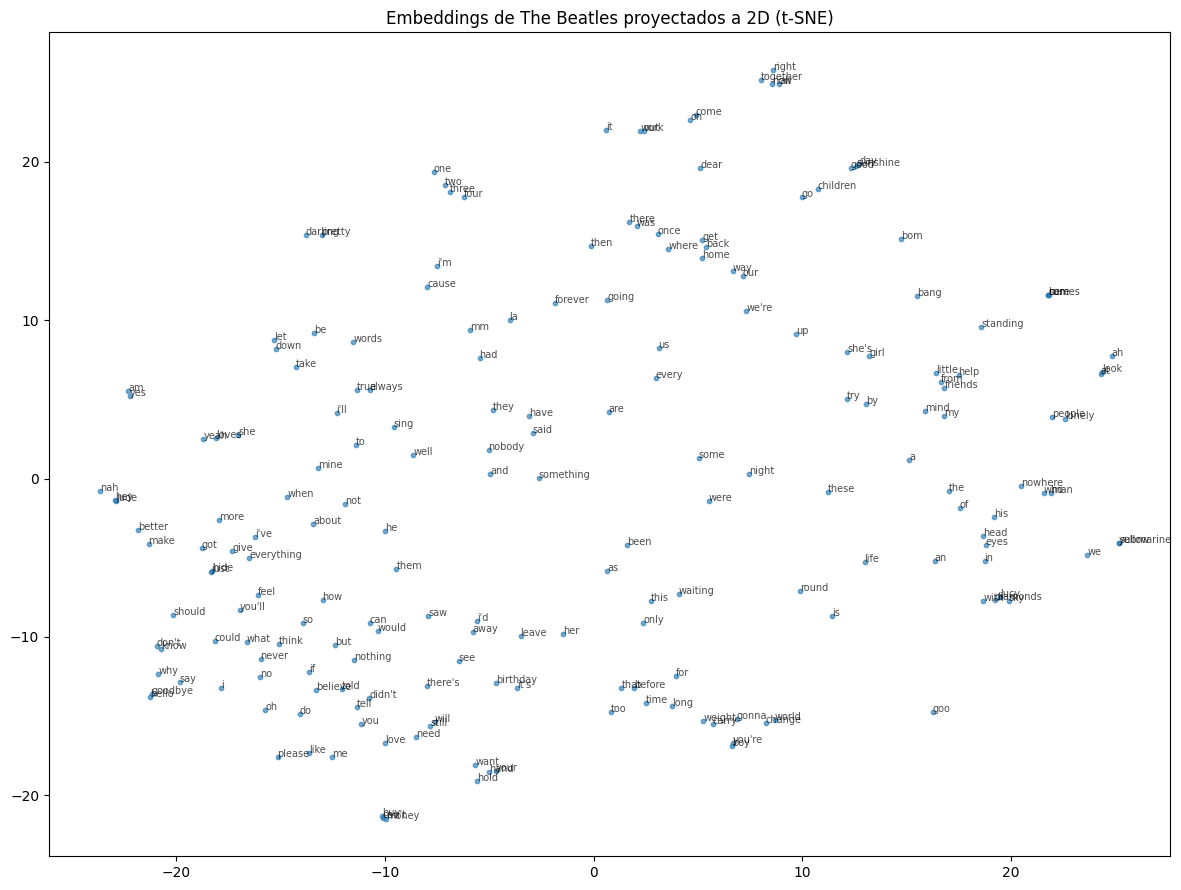

In [13]:
vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS = 200
plt.figure(figsize=(12, 9))
plt.scatter(vecs[:MAX_WORDS, 0], vecs[:MAX_WORDS, 1], s=10, alpha=0.6)
for i in range(MAX_WORDS):
    plt.annotate(labels[i], (vecs[i, 0], vecs[i, 1]), fontsize=7, alpha=0.7)
plt.title("Embeddings de The Beatles proyectados a 2D (t-SNE)")
plt.tight_layout()
plt.show()

In [14]:
# También se pueden guardar los vectores y labels como TSV para
# graficar en http://projector.tensorflow.org/
vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")
with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

---

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

---
# Resolución del Desafío 2

Para la consigna entrenamos **embeddings propios** sobre un corpus distinto al del ejemplo: las **letras de Bob Dylan** (`songs_dataset/bob-dylan.txt`). Es un autor con un catálogo grande y un vocabulario poético y temáticamente muy variado (amor, religión, política, naturaleza, viajes), lo que lo hace ideal para que los vectores capturen *cómo Dylan usa las palabras*.

Seguimos el mismo pipeline que el ejemplo (preprocesamiento → Word2Vec → ensayo → reducción a 2D) y agregamos una **interpretación en cada paso**, como pide la consigna.

## Parte 1 — Corpus propio y entrenamiento de embeddings

Cargamos el corpus tratando **cada línea (verso) como un documento**, igual que en el ejemplo. Reutilizamos el tokenizador liviano definido arriba y descartamos las líneas con un solo token (no aportan contexto).

In [15]:
with open("songs_dataset/bob-dylan.txt", encoding="utf-8") as f:
    lineas = [ln.strip() for ln in f if ln.strip()]

dylan_tokens = [text_to_word_sequence(ln) for ln in lineas]
dylan_tokens = [t for t in dylan_tokens if len(t) > 1]

print("Documentos (versos):", len(dylan_tokens))
print("Tokens totales      :", sum(len(t) for t in dylan_tokens))
print("Ejemplo:", dylan_tokens[0])

Documentos (versos): 5199
Tokens totales      : 38409
Ejemplo: ['there', 'must', 'be', 'some', 'way', 'out', 'of', 'here', 'said', 'the', 'joker', 'to', 'the', 'thief']


Para que la notebook sea **reproducible**, fijamos un `hashfxn` determinista. Por defecto gensim inicializa los vectores con el `hash()` de Python, que depende de `PYTHONHASHSEED` y cambia entre corridas; con un hash propio (MD5) los resultados son estables en cualquier máquina. Entrenamos un modelo **Skipgram** con `window=5`: como los versos son cortos (~7 tokens en promedio), una ventana amplia captura la coocurrencia dentro de casi todo el verso.

In [16]:
import hashlib

def det_hash(value):
    """Hash determinista (no depende de PYTHONHASHSEED)."""
    return int(hashlib.md5(str(value).encode("utf-8")).hexdigest(), 16)

dylan_model = Word2Vec(min_count=5,     # descarta palabras muy raras (hápax/ruido)
                       window=5,        # ventana amplia por versos cortos
                       vector_size=300,
                       negative=20,
                       workers=1,       # 1 worker + seed + hashfxn => determinista
                       sg=1,            # skipgram
                       seed=42,
                       hashfxn=det_hash)

dylan_model.build_vocab(dylan_tokens)
print("corpus_count :", dylan_model.corpus_count)
print("vocabulario  :", len(dylan_model.wv.index_to_key))

corpus_count : 5199
vocabulario  : 941


In [17]:
dylan_model.train(dylan_tokens,
                  total_examples=dylan_model.corpus_count,
                  epochs=30,
                  compute_loss=True,
                  callbacks=[callback()])

Loss after epoch 0: 369238.03125


Loss after epoch 1: 272135.65625


Loss after epoch 2: 274499.6875


Loss after epoch 3: 257708.25


Loss after epoch 4: 237727.75


...

Loss after epoch 26: 163235.0


Loss after epoch 27: 163795.0


Loss after epoch 28: 163297.0


Loss after epoch 29: 163377.0


(669087, 1152270)

### Skipgram vs CBOW
A modo de comparación entrenamos también un **CBOW** (`sg=0`) con los mismos hiperparámetros y miramos los vecinos de algunos términos.

In [18]:
cbow_model = Word2Vec(min_count=5, window=5, vector_size=300, negative=20,
                      workers=1, sg=0, seed=42, hashfxn=det_hash)
cbow_model.build_vocab(dylan_tokens)
cbow_model.train(dylan_tokens, total_examples=cbow_model.corpus_count, epochs=30)

for w in ["wind", "train", "river"]:
    sg = dylan_model.wv.most_similar(w, topn=6)
    cb = cbow_model.wv.most_similar(w, topn=6)
    print(f"\n{w!r}")
    print("  skipgram:", ", ".join(f"{a}:{b:.2f}" for a, b in sg))
    print("  cbow    :", ", ".join(f"{a}:{b:.2f}" for a, b in cb))


'wind'
  skipgram: blowin:0.79, answer:0.76, blows:0.72, blow:0.71, low:0.66, north:0.65
  cbow    : blow:0.81, sun:0.78, blowin:0.76, along:0.75, low:0.75, rain:0.75

'train'
  skipgram: bend:0.84, slow:0.81, cross:0.74, comin:0.68, rollin:0.67, track:0.67
  cbow    : slow:0.95, bend:0.91, comin:0.90, cross:0.84, rollin:0.82, tangled:0.81

'river'
  skipgram: flow:0.88, watch:0.73, dry:0.71, ol:0.71, rollin:0.71, shake:0.70
  cbow    : flow:0.90, watch:0.90, risin:0.88, bank:0.87, trees:0.85, lamb:0.85


### Interpretación — Parte 1

- **Tamaño del corpus.** Quedan **5199 versos / ~38 400 tokens** y un vocabulario de **941 palabras** (con `min_count=5`). Es un corpus bastante más grande y variado que el del ejemplo (Beatles: 1846 docs, 445 palabras), lo que ayuda a que los vectores tengan contexto suficiente.
- **Por qué Skipgram.** Con un corpus chico y vocabulario poético, muchas palabras de interés aparecen pocas veces; *skipgram* modela mejor las palabras infrecuentes que CBOW, por eso lo elegimos como modelo principal.
- **Hiperparámetros.** `window=5` (versos cortos), `vector_size=300`, `negative=20`, `min_count=5` para sacar hápax y ruido. La **curva de loss baja** de forma sostenida a lo largo de las 30 épocas (de ~369 k a ~163 k, con pequeñas oscilaciones puntuales) -> el modelo está aprendiendo y no diverge.
- **Skipgram vs CBOW.** CBOW devuelve **cosenos más altos y concentrados** (p. ej. `train->slow` ~ 0.95) y vecinos más "de contexto amplio" (`wind->sun, rain`). Skipgram da cosenos algo más bajos pero destapa asociaciones **más específicas y raras**: para `wind` aparece `answer` y `north`, es decir, reconstruye el verso de *Blowin' in the Wind* ("the answer is blowin' in the wind"). Es exactamente lo que predice la teoría sobre ambas arquitecturas.

## Parte 2 — Términos de interés (más y menos similares)

Elegimos **manualmente** términos temáticos del universo de Dylan y buscamos sus vecinos más similares. Después usamos `most_similar(negative=...)` para los "menos similares".

In [19]:
terminos = ["wind", "train", "lord", "river", "blues", "love", "heart", "money", "time"]

for w in terminos:
    sims = dylan_model.wv.most_similar(positive=[w], topn=8)
    print(f"{w:7s} -> " + ", ".join(f"{a} ({b:.2f})" for a, b in sims))

wind    -> blowin (0.79), answer (0.76), blows (0.72), blow (0.71), low (0.66), north (0.65), which (0.63), wicked (0.62)
train   -> bend (0.84), slow (0.81), cross (0.74), comin (0.68), rollin (0.67), track (0.67), runnin (0.67), wicked (0.65)
lord    -> thank (0.84), honey (0.79), devil (0.78), above (0.74), mercy (0.71), mister (0.67), jones (0.66), guns (0.66)
river   -> flow (0.88), watch (0.73), dry (0.71), ol (0.71), rollin (0.71), shake (0.70), keeps (0.70), spirit (0.67)
blues   -> memphis (0.91), tombstone (0.90), bit (0.81), sing (0.74), again (0.70), memories (0.67), nobody (0.62), flowers (0.61)
love    -> feelin (0.62), shot (0.59), help (0.58), already (0.58), doctor (0.58), whiskey (0.57), breath (0.57), first (0.57)
heart   -> burnin (0.75), yearnin (0.75), soul (0.66), mouth (0.59), follow (0.59), breath (0.58), buy (0.56), kiss (0.56)
money   -> hurt (0.74), work (0.73), gotta (0.70), feelings (0.70), cannot (0.69), pay (0.69), worth (0.67), nose (0.66)
time    -> ag

In [20]:
# Términos MENOS similares (operación con vector negativo)
for w in ["love", "money", "war", "god"]:
    if w in dylan_model.wv:
        sims = dylan_model.wv.most_similar(negative=[w], topn=6)
        print(f"NEG {w:6s} -> " + ", ".join(f"{a} ({b:.2f})" for a, b in sims))

NEG love   -> gather (-0.02), called (-0.03), upon (-0.05), home (-0.06), on (-0.06), storms (-0.06)
NEG money  -> been (-0.09), river (-0.11), twenty (-0.13), ol (-0.14), there's (-0.15), town (-0.16)
NEG war    -> does (-0.08), knew (-0.11), isn't (-0.12), were (-0.13), honest (-0.13), here (-0.13)
NEG god    -> day (-0.03), around (-0.09), at (-0.10), open (-0.10), road (-0.12), so (-0.12)


### Interpretación — Parte 2

**Más similares** — el modelo captura campos semánticos y coocurrencias muy reconocibles (vecinos top-6 tal como salen en la celda de arriba):

| Término | Vecinos top | Lectura |
|---|---|---|
| `wind` | blowin, answer, blows, blow, low, north | Reconstruye *Blowin' in the Wind* ("the answer is blowin' in the wind"). |
| `train` | bend, slow, cross, comin, rollin, track | Campo del **tren / movimiento** (*Slow Train Coming*). |
| `lord` | thank, honey, devil, above, mercy, mister | Registro **religioso / de plegaria** (etapa gospel). |
| `blues` | memphis, tombstone, bit, sing | **Títulos de canciones** (*Memphis Blues Again*, *Tombstone Blues*): captura coocurrencia en estribillos más que semántica. |
| `river` | flow, watch, dry, ol, rollin, shake | Imágenes del **agua / paisaje** (sobre todo `flow`, `dry`, `rollin`). |
| `love` | feelin, shot, help, already, doctor, whiskey | Más **difusa**: es una palabra muy frecuente y polisémica, por eso sus vecinos son heterogéneos (`shot`, `whiskey`, `doctor`). |

**Menos similares** — los valores son todos **cercanos a 0** (entre -0.02 y -0.16). Es un resultado esperable e interesante: en un corpus de **un solo autor** casi no hay pares de palabras fuertemente "opuestas". La operación `negative` no devuelve antónimos, sino palabras prácticamente **ortogonales** (función o temas no relacionados). Conclusión: en este corpus el "menos similar" es **poco informativo**; lo valioso está en los más similares.

## Parte 3 — Reducción a 2D y elección de `MAX_WORDS`

Proyectamos las 941 palabras a 2D con **t-SNE** (`init="pca"`, `perplexity=30`). El punto fino es elegir **cuántas y cuáles** palabras mostrar para que la visualización sea legible.

In [21]:
dylan_vecs, dylan_labels = reduce_dimensions(dylan_model)
print("coordenadas 2D:", dylan_vecs.shape)

coordenadas 2D: (941, 2)


**Primer intento (como el ejemplo): las 200 palabras más frecuentes.**

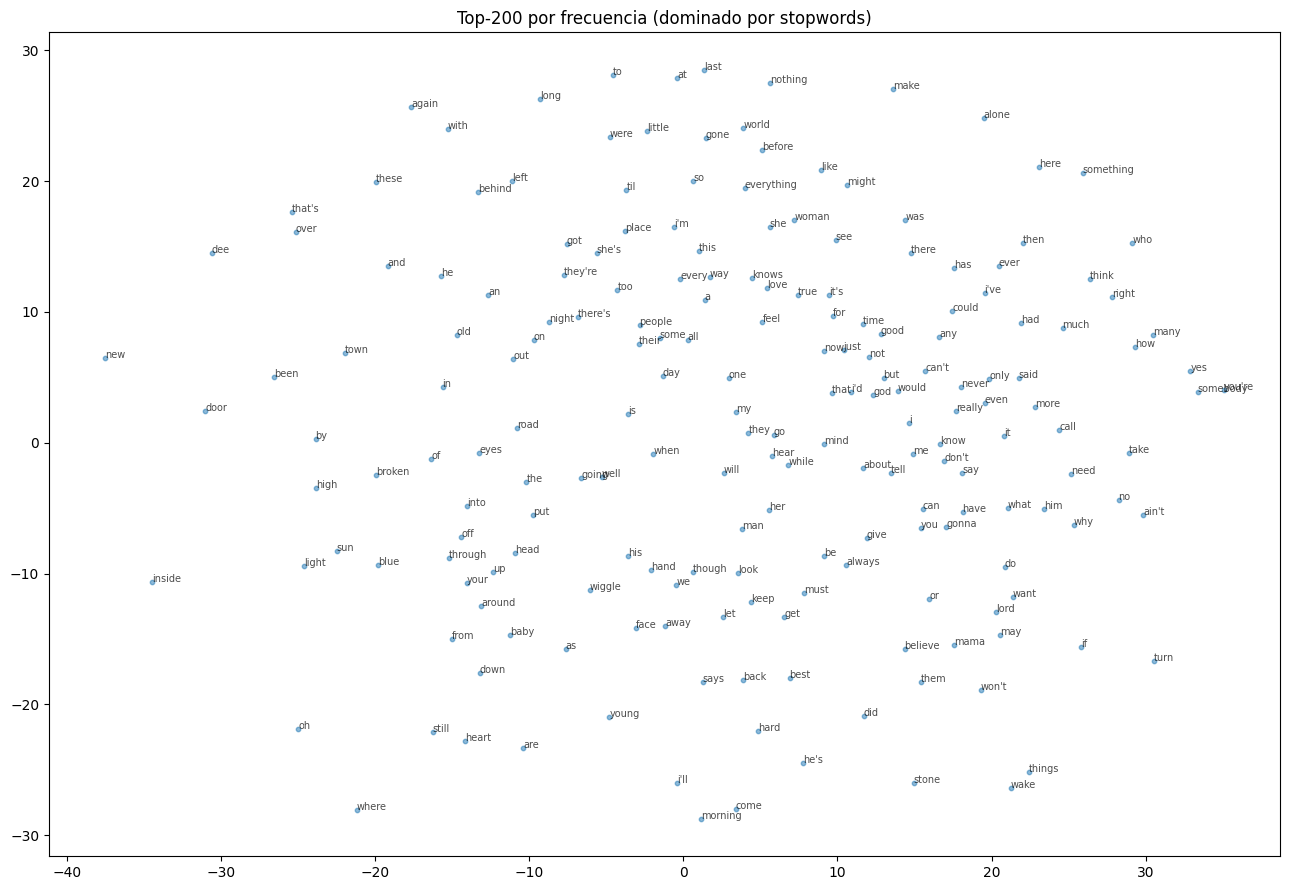

In [22]:
MAX_WORDS = 200
plt.figure(figsize=(13, 9))
plt.scatter(dylan_vecs[:MAX_WORDS, 0], dylan_vecs[:MAX_WORDS, 1], s=10, alpha=0.5)
for i in range(MAX_WORDS):
    plt.annotate(dylan_labels[i], (dylan_vecs[i, 0], dylan_vecs[i, 1]), fontsize=7, alpha=0.7)
plt.title("Top-200 por frecuencia (dominado por stopwords)")
plt.tight_layout()
plt.show()

El problema es que las palabras más frecuentes son casi todas **stopwords** (`the`, `you`, `i`, `to`, `and`...): la nube central queda ilegible y la estructura que se ve es **gramatical**, no temática. Filtramos stopwords y nos quedamos con las **150 palabras de contenido** más frecuentes — así las etiquetas no se solapan y emergen los grupos temáticos.

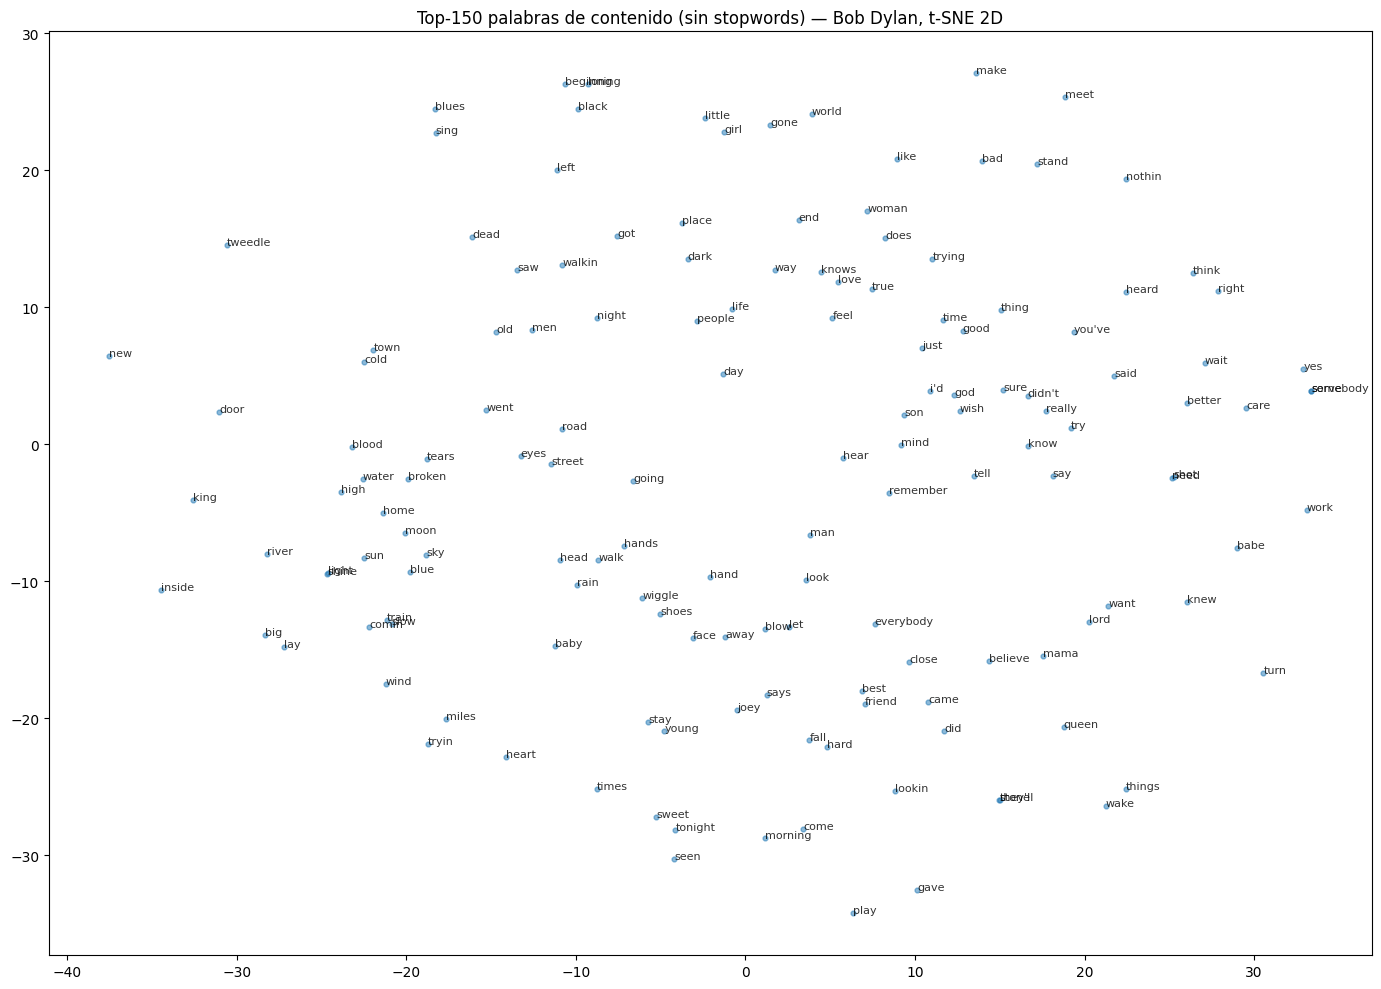

In [23]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

extra = {"i'm","don't","it's","that's","there's","ain't","can't","won't","i'll",
         "i've","she's","he's","you're","they're","gonna","gotta","wanna","til",
         "oh","yeah","la","na","dee","ev'rybody","ol","mr"}
STOP = set(ENGLISH_STOP_WORDS) | extra

mask = np.array([w not in STOP and len(w) > 2 for w in dylan_labels])
idx_content = np.where(mask)[0]

os.makedirs("img", exist_ok=True)   # asegura que la carpeta exista al correr de cero
MAX_WORDS = 150
sel = idx_content[:MAX_WORDS]
xy = dylan_vecs[sel]
words = dylan_labels[sel]

plt.figure(figsize=(14, 10))
plt.scatter(xy[:, 0], xy[:, 1], s=12, alpha=0.5)
for (x, y), w in zip(xy, words):
    plt.annotate(w, (x, y), fontsize=8, alpha=0.8)
plt.title(f"Top-{MAX_WORDS} palabras de contenido (sin stopwords) — Bob Dylan, t-SNE 2D")
plt.tight_layout()
plt.savefig("img/dylan_2d.png", dpi=120, bbox_inches="tight")
plt.show()

### Interpretación — Parte 3

- **`MAX_WORDS` no es solo "cuántas" sino "cuáles".** Con las 200 palabras más frecuentes el gráfico se satura y, peor, muestra sobre todo stopwords: la visualización no es adecuada.
- Filtrando stopwords y quedándonos con las **150 palabras de contenido** más frecuentes, las etiquetas dejan de solaparse y aparecen **vecindarios temáticos** claros. Ese fue el criterio para elegir `MAX_WORDS`: el mayor número de términos que todavía permite leer las etiquetas y distinguir grupos.
- t-SNE preserva la **estructura local**: palabras que el modelo considera parecidas quedan cerca, por eso es la herramienta adecuada para *ver* los grupos que ya intuíamos en la Parte 2.

## Parte 4 — Grupos de palabras y conclusiones

Inspeccionando el gráfico anterior se forman varios **grupos pequeños**. Para documentarlos, generamos un **zoom (captura)** de cada región: definimos el recuadro a partir de las coordenadas de unas palabras semilla y mostramos todo lo que cae dentro. Las capturas se guardan en `img/` y se pegan en las celdas de texto siguientes.

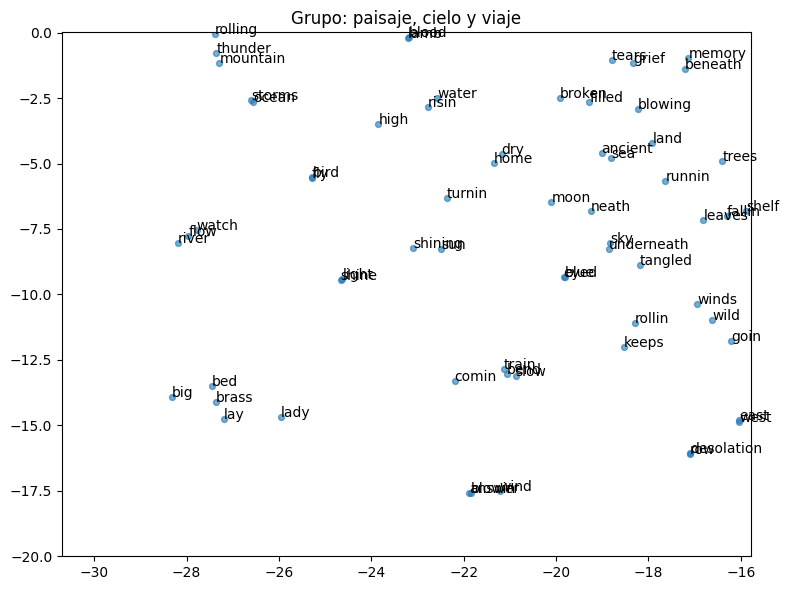

cluster_paisaje: [np.str_('ancient'), np.str_('answer'), np.str_('bed'), np.str_('bend'), np.str_('beneath'), np.str_('big'), np.str_('bird'), np.str_('blood'), np.str_('blowin'), np.str_('blowing'), np.str_('blue'), np.str_('brass'), np.str_('broken'), np.str_('comin'), np.str_('desolation'), np.str_('dry'), np.str_('east'), np.str_('eyed'), np.str_('fallin'), np.str_('filled'), np.str_('flow'), np.str_('fly'), np.str_('goin'), np.str_('grief'), np.str_('high'), np.str_('home'), np.str_('keeps'), np.str_('lady'), np.str_('lamb'), np.str_('land'), np.str_('lay'), np.str_('leaves'), np.str_('light'), np.str_('memory'), np.str_('moon'), np.str_('mountain'), np.str_('neath'), np.str_('ocean'), np.str_('risin'), np.str_('river'), np.str_('rollin'), np.str_('rolling'), np.str_('row'), np.str_('runnin'), np.str_('sea'), np.str_('shelf'), np.str_('shine'), np.str_('shining'), np.str_('sky'), np.str_('slow'), np.str_('storms'), np.str_('sun'), np.str_('tangled'), np.str_('tears'), np.str_('thu

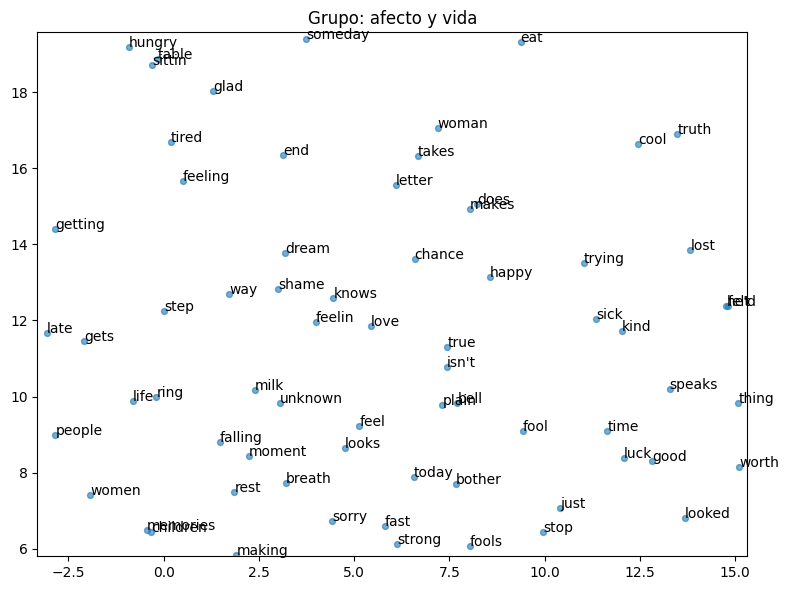

cluster_afecto: [np.str_('bell'), np.str_('bother'), np.str_('breath'), np.str_('chance'), np.str_('children'), np.str_('cool'), np.str_('does'), np.str_('dream'), np.str_('eat'), np.str_('end'), np.str_('falling'), np.str_('fast'), np.str_('feel'), np.str_('feelin'), np.str_('feeling'), np.str_('felt'), np.str_('fool'), np.str_('fools'), np.str_('gets'), np.str_('getting'), np.str_('glad'), np.str_('good'), np.str_('happy'), np.str_("he'd"), np.str_('hungry'), np.str_("isn't"), np.str_('just'), np.str_('kind'), np.str_('knows'), np.str_('late'), np.str_('letter'), np.str_('life'), np.str_('looked'), np.str_('looks'), np.str_('lost'), np.str_('love'), np.str_('luck'), np.str_('makes'), np.str_('making'), np.str_('memories'), np.str_('milk'), np.str_('moment'), np.str_('people'), np.str_('plain'), np.str_('rest'), np.str_('ring'), np.str_('shame'), np.str_('sick'), np.str_('sittin'), np.str_('someday'), np.str_('sorry'), np.str_('speaks'), np.str_('step'), np.str_('stop'), np.str_('stro

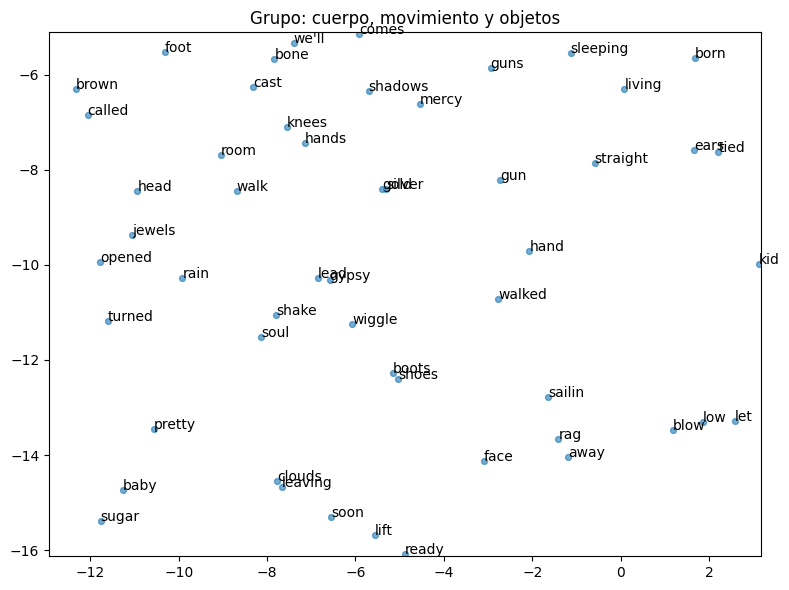

cluster_cuerpo: [np.str_('away'), np.str_('baby'), np.str_('blow'), np.str_('bone'), np.str_('boots'), np.str_('born'), np.str_('brown'), np.str_('called'), np.str_('cast'), np.str_('clouds'), np.str_('comes'), np.str_('ears'), np.str_('face'), np.str_('foot'), np.str_('gold'), np.str_('gun'), np.str_('guns'), np.str_('gypsy'), np.str_('hand'), np.str_('hands'), np.str_('head'), np.str_('jewels'), np.str_('kid'), np.str_('knees'), np.str_('lead'), np.str_('leaving'), np.str_('let'), np.str_('lift'), np.str_('living'), np.str_('low'), np.str_('mercy'), np.str_('opened'), np.str_('pretty'), np.str_('rag'), np.str_('rain'), np.str_('ready'), np.str_('room'), np.str_('sailin'), np.str_('shadows'), np.str_('shake'), np.str_('shoes'), np.str_('silver'), np.str_('sleeping'), np.str_('soon'), np.str_('soul'), np.str_('straight'), np.str_('sugar'), np.str_('tied'), np.str_('turned'), np.str_('walk'), np.str_('walked'), np.str_("we'll"), np.str_('wiggle')]


In [24]:
os.makedirs("img", exist_ok=True)

# coordenadas de TODAS las palabras de contenido (para los zooms)
xy_c = dylan_vecs[idx_content]
w_c = dylan_labels[idx_content]

def capturar(nombre, semillas, margen=2.5, titulo=""):
    """Dibuja y guarda un zoom de la región que contiene las palabras semilla."""
    pres = [s for s in semillas if s in set(w_c)]
    P = np.array([xy_c[list(w_c).index(s)] for s in pres])
    x0, x1 = P[:, 0].min() - margen, P[:, 0].max() + margen
    y0, y1 = P[:, 1].min() - margen, P[:, 1].max() + margen
    en_caja = (xy_c[:, 0] >= x0) & (xy_c[:, 0] <= x1) & (xy_c[:, 1] >= y0) & (xy_c[:, 1] <= y1)
    plt.figure(figsize=(8, 6))
    plt.scatter(xy_c[en_caja, 0], xy_c[en_caja, 1], s=18, alpha=0.6)
    for (x, y), w in zip(xy_c[en_caja], w_c[en_caja]):
        plt.annotate(w, (x, y), fontsize=10)
    plt.title(titulo)
    plt.xlim(x0, x1); plt.ylim(y0, y1)
    plt.tight_layout()
    plt.savefig(f"img/{nombre}.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"{nombre}: {sorted(w_c[en_caja])}")

capturar("cluster_paisaje",
         ["sun","moon","sky","water","river","shine","light","blue","fly","sea","wind","train","slow","comin","rollin"],
         titulo="Grupo: paisaje, cielo y viaje")
capturar("cluster_afecto",
         ["love","time","feel","good","true","woman","life","kind","dream"],
         titulo="Grupo: afecto y vida")
capturar("cluster_cuerpo",
         ["face","hand","head","hands","shoes","walk","knees","blow"],
         margen=2.0, titulo="Grupo: cuerpo, movimiento y objetos")

### Grupo 1 — Paisaje, cielo y viaje

![Grupo paisaje](img/cluster_paisaje.png)

Abajo a la izquierda se concentra el **imaginario natural** de Dylan: `sun`, `moon`, `sky`, `water`, `river`, `sea`, `light`, `shine`, `blue`, `fly`. Pegado debajo aparece un subgrupo de **movimiento/viaje** — `train`, `slow`, `comin`, `rollin`, `wind` — que conecta el paisaje con el desplazamiento (*Slow Train Coming*, *Blowin' in the Wind*). Es el núcleo de la poética dylaniana: naturaleza + camino.

### Grupo 2 — Afecto y vida

![Grupo afecto](img/cluster_afecto.png)

Arriba al centro se agrupa el vocabulario **emocional y abstracto**: `love`, `feel`, `true`, `dream`, `woman`, `life`, `time`, `good`, `kind`. Son palabras que aparecen en contextos parecidos (declaraciones, reflexiones) y por eso el modelo las ubica juntas. Notar que `heart`, pese a ser afectiva, **no** cae acá sino junto a `burnin`/`yearnin` (emoción más física): la similitud es por **uso**, no por nuestro mapa mental de sinónimos.

### Grupo 3 — Cuerpo, movimiento y objetos

![Grupo cuerpo](img/cluster_cuerpo.png)

En la zona central-inferior se forma un grupo de vocabulario **concreto y material**, que contrasta con el grupo abstracto anterior:

- **Partes del cuerpo**: `foot`, `bone`, `ears`, `face`, `hand`, `hands`, `head`, `knees`.
- **Calzado y acciones físicas**: `boots`, `shoes`, `walk`, `walked`, `shake`, `lift`, `turned`, `opened`, `blow`.
- **Objetos**: `gold`, `silver`, `jewels`, `guns`.

Tiene sentido: Dylan describe escenas muy **corporales y físicas**, y todas estas palabras coocurren en versos narrativos concretos. Es la contracara del grupo de afecto: acá vive lo tangible (cuerpo, gesto, cosas) y allá lo abstracto (amor, vida, tiempo).

### Conclusiones

- **Se valida la hipótesis distribucional**: entrenando Word2Vec sobre un corpus propio (Bob Dylan) los vectores capturan asociaciones reconocibles — campos semánticos (`wind`/`blowin`/`answer`), títulos de canciones (`blues`/`memphis`/`tombstone`) y grupos temáticos visibles en 2D (paisaje, afecto, cuerpo).
- Lo que captura es **tema y coocurrencia**, no semántica fina ni antónimos: `love` queda difusa, los "menos similares" son ruido cercano a 0, y `heart` se agrupa con `burnin`/`yearnin` (por *uso*) y no con sus sinónimos.
- Los grupos **no son perfectos**: es un corpus de **un solo autor**, con líneas cortas y vocabulario chico (941 palabras), así que hay fronteras difusas y algún vecino espurio por coocurrencia casual.
- **Cómo mejorarlo**: más corpus (varios autores/discos), **lematizar** para unificar las formas con apóstrofo (`comin`/`coming`, `blowin`/`blowing`), y comparar contra **embeddings pre-entrenados** (GloVe/FastText) para distinguir lo que es propio del estilo de Dylan de lo que es lenguaje general.